# Task 5: Polynomial regression with hyperparameter tuning

In [44]:
# Read the data
import pandas as pa
import numpy as np
data = open("inc_utf.csv").readlines()
# Prepare the data with a list and comprehension
cleaned_data = [ (int(region[:2]),int(age.replace(" years","").replace("+","")), float(income))
                for row in data[1:]
                 for _, region, age, income in [row.strip().split(",")]]
# Task 3.2
df = pa.DataFrame(cleaned_data, columns=["region", "age", "income"])
data_to_model = df.groupby("age")["income"].mean().to_frame().reset_index().sort_values(by=["age"], ascending=True).to_numpy()
rng = np.random.default_rng(42)
rng.shuffle(data_to_model)
train_set_size = int(len(data_to_model) * 0.8)
train_set, test_set = data_to_model[:train_set_size], data_to_model[train_set_size:]

age_train = train_set[:,0]
income_train = train_set[:,1]

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
poly_features = PolynomialFeatures(degree=3, include_bias=False)
age_train_2d = age_train.reshape(-1, 1)
X_poly = poly_features.fit_transform(age_train_2d)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, income_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[55.16,-0.87, 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-684.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[2454656.63, 3614.07, 10.76]"


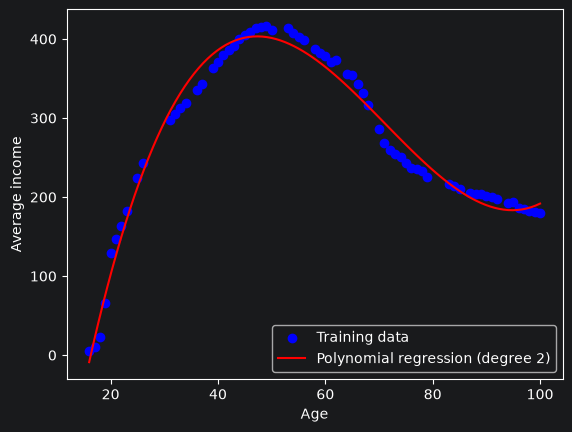

In [46]:
plt.scatter(age_train, income_train, color="blue", label="Training data")

age_range = np.linspace(age_train.min(), age_train.max(), 100).reshape(-1, 1)
age_range_poly = poly_features.fit_transform(age_range)
income_pred = lin_reg.predict(age_range_poly)

plt.plot(age_range, income_pred, color="red", label="Polynomial regression (degree 3)")
plt.xlabel("Age")
plt.ylabel("Average income")
plt.legend()
plt.show()